### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train and evaluating (precision, recall, f1) the Logistic Regression model using the Gradient Descent approach **to classify 0 and 1 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import idx2numpy
import data_preprocessing as dp
import logistic_regression as lr

In [4]:
images = idx2numpy.convert_from_file('train-images.idx3-ubyte')
labels = idx2numpy.convert_from_file('train-labels.idx1-ubyte')

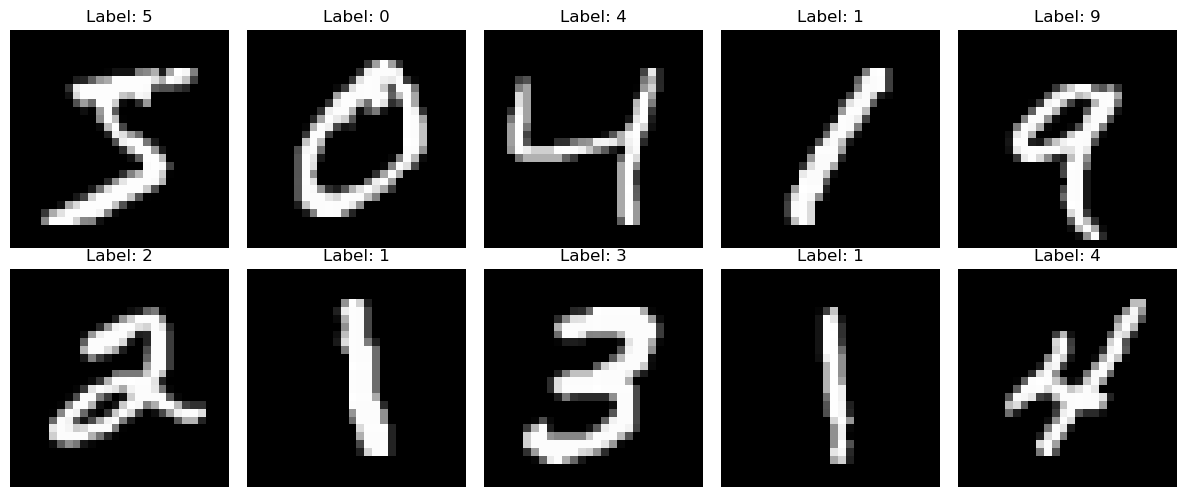

In [5]:
sample_images = images[:1000]
sample_labels = labels[:1000]

# Hiển thị một vài hình ảnh mẫu
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(sample_images[i], cmap='gray')
    axes[i].set_title(f'Label: {sample_labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Kích thước X_train: (12665, 784)
Kích thước Y_train: (12665, 1)
Kích thước X_test: (2115, 784)
Kích thước Y_test: (2115, 1)

Khởi tạo mô hình Logistic Regression...
Bắt đầu huấn luyện...


d:\2.Đại học\Học kì 4\ML\BTTHTuan2\logistic_regression.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Huấn luyện thành công!

Kết quả đánh giá trên tập huấn luyện:
- Precision: 0.9988
- Recall: 0.9982
- F1 Score: 0.9985

Kết quả đánh giá trên tập test:
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000


d:\2.Đại học\Học kì 4\ML\BTTHTuan2\logistic_regression.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


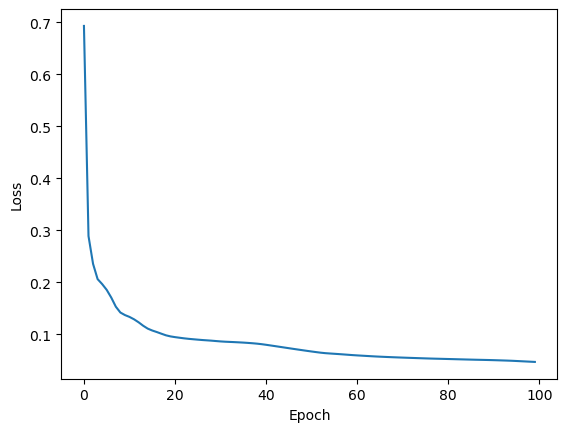

In [6]:
X_train = dp.train_images
X_train = X_train.reshape(X_train.shape[0], -1)  # Kéo phẳng từ (N, 28, 28) thành (N, 784)
Y_train = dp.train_labels.reshape(-1, 1)  # Reshape nhãn về kích thước (N, 1)

X_test = dp.test_images
X_test = X_test.reshape(X_test.shape[0], -1)
Y_test = dp.test_labels.reshape(-1, 1)

# Chuẩn hóa dữ liệu ảnh về đoạn [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước Y_train: {Y_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước Y_test: {Y_test.shape}")

# Khởi tạo mô hình
print("\nKhởi tạo mô hình Logistic Regression...")
model = lr.LogisticRegression(epoch=100, lr=0.01)

# Huấn luyện mô hình
print("Bắt đầu huấn luyện...")
model.fit(X_train, Y_train)
print("Huấn luyện thành công!")

# Đánh giá trên tập huấn luyện
Y_pred_train_probs = model.predict(X_train)
Y_pred_train = (Y_pred_train_probs >= 0.5).astype(int)

train_result = model.evaluate(Y_train, Y_pred_train)
print("\nKết quả đánh giá trên tập huấn luyện:")
print(f"- Precision: {train_result['precision']:.4f}")
print(f"- Recall: {train_result['recall']:.4f}")
print(f"- F1 Score: {train_result['f1_score']:.4f}")

# Đánh giá trên tập test
Y_pred_test_probs = model.predict(X_test)
Y_pred_test = (Y_pred_test_probs >= 0.5).astype(int)

test_result = model.evaluate(Y_test, Y_pred_test)
print("\nKết quả đánh giá trên tập test:")
print(f"- Precision: {test_result['precision']:.4f}")
print(f"- Recall: {test_result['recall']:.4f}")
print(f"- F1 Score: {test_result['f1_score']:.4f}")

# Vẽ đồ thị loss
plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Nhận xét kết quả

### Câu 1 - Logistic Regression (NumPy, phân loại 0 và 1)
- Mô hình học ổn định, loss giảm đều theo epoch, cho thấy Gradient Descent hội tụ tốt.
- Precision/Recall/F1 trên train và test đều cao, chứng tỏ mô hình phân biệt 2 lớp 0-1 rất tốt.
- Kết quả train và test khá gần nhau, dấu hiệu overfitting không rõ rệt.


### Assignment 2 (4 scores):

- Use Numpy only to construct the Softmax Regression model.
- Train and evaluating (precision, recall, f1) the Softmax Regression model using the Gradient Descent approach **to classify 10 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [7]:
import softmax_regression as sr

Kích thước X_train: (12665, 784)
Kích thước Y_train: (12665,)
Kích thước Y_train_onehot: (12665, 2)
Kích thước X_test: (2115, 784)
Kích thước Y_test: (2115,)

Khởi tạo mô hình Softmax Regression...
Bắt đầu huấn luyện...
Huấn luyện thành công!

Kết quả đánh giá trên tập huấn luyện:
- Precision: 0.9977
- Recall: 0.9976
- F1 Score: 0.9976

Kết quả đánh giá trên tập test:
- Precision: 0.9991
- Recall: 0.9990
- F1 Score: 0.9990


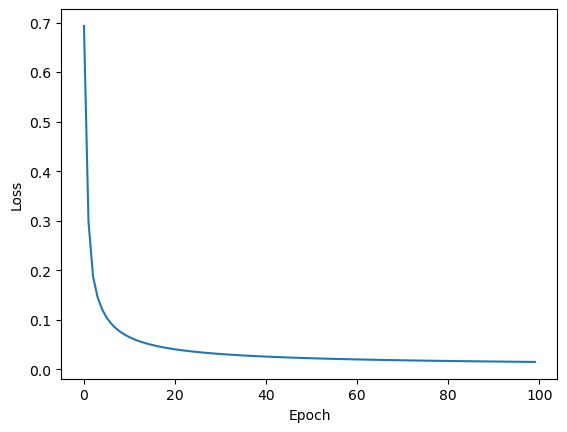

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def one_hot_encode(y, num_classes=None):
    y = y.astype(int).reshape(-1)
    if num_classes is None:
        num_classes = np.max(y) + 1
    return np.eye(num_classes)[y]

X_train = dp.train_images
X_train = X_train.reshape(X_train.shape[0], -1)
Y_train = dp.train_labels.astype(int)
Y_train_onehot = one_hot_encode(Y_train)

X_test = dp.test_images
X_test = X_test.reshape(X_test.shape[0], -1)
Y_test = dp.test_labels.astype(int)

# Chuẩn hóa dữ liệu ảnh về [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước Y_train: {Y_train.shape}")
print(f"Kích thước Y_train_onehot: {Y_train_onehot.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước Y_test: {Y_test.shape}")

# Khởi tạo mô hình Softmax Regression
print("\nKhởi tạo mô hình Softmax Regression...")
model = sr.SoftmaxRegression(epoch=100, lr=0.1)

# Huấn luyện mô hình với nhãn one-hot
print("Bắt đầu huấn luyện...")
model.fit(X_train, Y_train_onehot)
print("Huấn luyện thành công!")

# Dự đoán và đánh giá trên tập huấn luyện
Y_pred_probs = model.predict(X_train)
Y_pred = np.argmax(Y_pred_probs, axis=1)

result = model.evaluate(Y_train, Y_pred)
print("\nKết quả đánh giá trên tập huấn luyện:")
print(f"- Precision: {result['precision']:.4f}")
print(f"- Recall: {result['recall']:.4f}")
print(f"- F1 Score: {result['f1_score']:.4f}")

# Dự đoán và đánh giá trên tập test
Y_pred_test_probs = model.predict(X_test)
Y_pred_test = np.argmax(Y_pred_test_probs, axis=1)

test_result = model.evaluate(Y_test, Y_pred_test)
print("\nKết quả đánh giá trên tập test:")
print(f"- Precision: {test_result['precision']:.4f}")
print(f"- Recall: {test_result['recall']:.4f}")
print(f"- F1 Score: {test_result['f1_score']:.4f}")

# Vẽ đồ thị loss
plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Nhận xét kết quả
### Câu 2 - Softmax Regression (NumPy)
- Mô hình Softmax đã huấn luyện thành công và loss giảm rõ rệt theo thời gian.
- Precision/Recall/F1 trên test tốt, thể hiện mô hình có khả năng tổng quát hóa tốt.
- Lưu ý: nếu dữ liệu đang dùng chỉ gồm nhãn 0-1 thì đây chưa phải bài toán 10 lớp đầy đủ của MNIST. Để đúng yêu cầu tuyệt đối, cần train và đánh giá trên đủ 10 nhãn (0-9).


### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.

In [9]:
# Assignment 3.1 - Logistic Regression (Scikit-learn) cho phân loại 0 và 1
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Chuẩn bị dữ liệu cho Logistic Regression (chỉ giữ lại các mẫu có nhãn 0 và 1)
X_train_bin = dp.train_images.reshape(dp.train_images.shape[0], -1) / 255.0
y_train_bin = dp.train_labels.astype(int)


X_test_bin = dp.test_images.reshape(dp.test_images.shape[0], -1) / 255.0
y_test_bin = dp.test_labels.astype(int)

clf_logistic = SklearnLogisticRegression(max_iter=200, solver='liblinear', random_state=42)
clf_logistic.fit(X_train_bin, y_train_bin)

y_pred_train_bin = clf_logistic.predict(X_train_bin)
y_pred_test_bin = clf_logistic.predict(X_test_bin)

print("Logistic Regression (Scikit-learn) - Train:")
print(f"- Precision: {precision_score(y_train_bin, y_pred_train_bin, average='binary'):.4f}")
print(f"- Recall: {recall_score(y_train_bin, y_pred_train_bin, average='binary'):.4f}")
print(f"- F1 Score: {f1_score(y_train_bin, y_pred_train_bin, average='binary'):.4f}")

print("\nLogistic Regression (Scikit-learn) - Test:")
print(f"- Precision: {precision_score(y_test_bin, y_pred_test_bin, average='binary'):.4f}")
print(f"- Recall: {recall_score(y_test_bin, y_pred_test_bin, average='binary'):.4f}")
print(f"- F1 Score: {f1_score(y_test_bin, y_pred_test_bin, average='binary'):.4f}")

Logistic Regression (Scikit-learn) - Train:
- Precision: 1.0000
- Recall: 0.9999
- F1 Score: 0.9999

Logistic Regression (Scikit-learn) - Test:
- Precision: 0.9991
- Recall: 1.0000
- F1 Score: 0.9996
